In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

from imblearn.over_sampling import SMOTE

In [35]:
df = pd.read_csv("/content/creditcard.csv")

print(df.head())

print(df.shape)

print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [36]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [37]:
print(df.duplicated().sum())

df = df.drop_duplicates()

1081


Class
0    283253
1       473
Name: count, dtype: int64


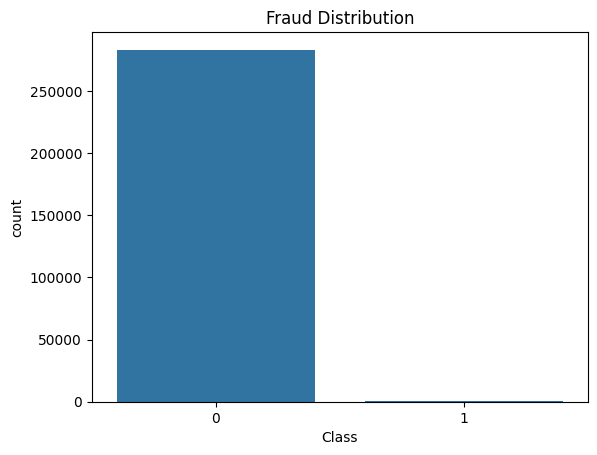

In [38]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)

plt.title("Fraud Distribution")

plt.show()

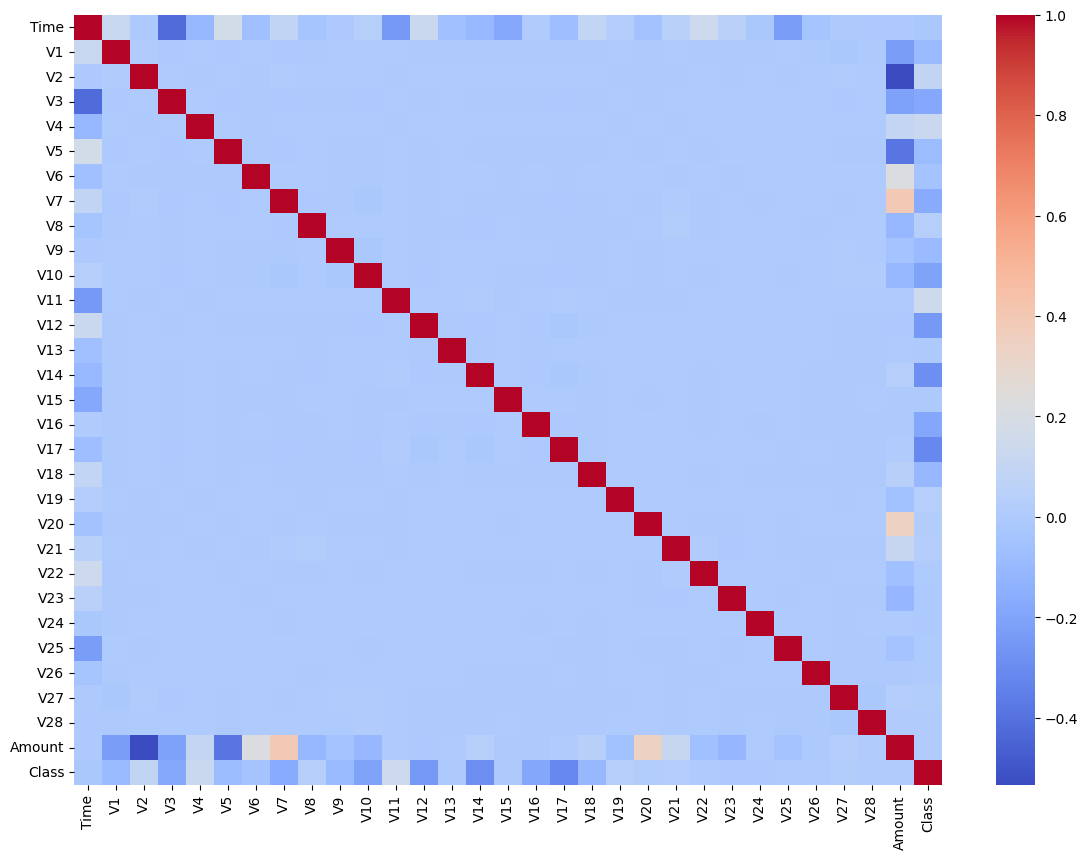

In [39]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.show()

In [40]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

df['Time'] = scaler.fit_transform(df[['Time']])

In [41]:
X = df.drop('Class', axis=1)

y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y
)

In [42]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [43]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [32]:
rf = RandomForestClassifier(

n_estimators=200,

random_state=42

)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [33]:
mlp = MLPClassifier(

hidden_layer_sizes=(64,32),

max_iter=100,

random_state=42

)

mlp.fit(X_train_smote, y_train_smote)

mlp_pred = mlp.predict(X_test)

print(classification_report(y_test, mlp_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.76      0.77        95

    accuracy                           1.00     56746
   macro avg       0.89      0.88      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [44]:
def evaluate(model_name, y_true, y_pred):

    print(model_name)

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision :", precision_score(y_true, y_pred))

    print("Recall :", recall_score(y_true, y_pred))

    print("F1 :", f1_score(y_true, y_pred))

    print("ROC AUC :", roc_auc_score(y_true, y_pred))

    print(confusion_matrix(y_true, y_pred))

    print(classification_report(y_true, y_pred))


In [45]:
evaluate("Logistic Regression", y_test, lr_pred)

evaluate("Random Forest", y_test, rf_pred)

evaluate("Neural Network", y_test, mlp_pred)

Logistic Regression
Accuracy : 0.9737250202657456
Precision : 0.05313700384122919
Recall : 0.8736842105263158
F1 : 0.10018105009052504
ROC AUC : 0.923788496324216
[[55172  1479]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Random Forest
Accuracy : 0.9994889507630493
Precision : 0.9230769230769231
Recall : 0.7578947368421053
F1 : 0.8323699421965318
ROC AUC : 0.8788944126038563
[[56645     6]
 [   23    72]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1

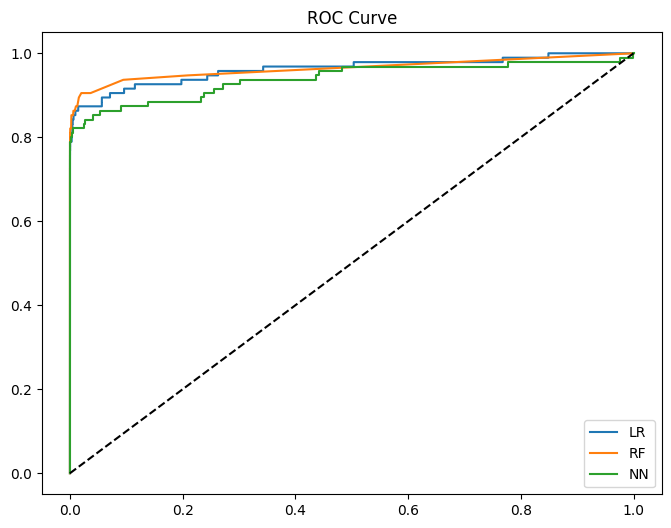

In [46]:
plt.figure(figsize=(8,6))

for model, name in [(lr,"LR"), (rf,"RF"), (mlp,"NN")]:

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.legend()

plt.title("ROC Curve")

plt.show()

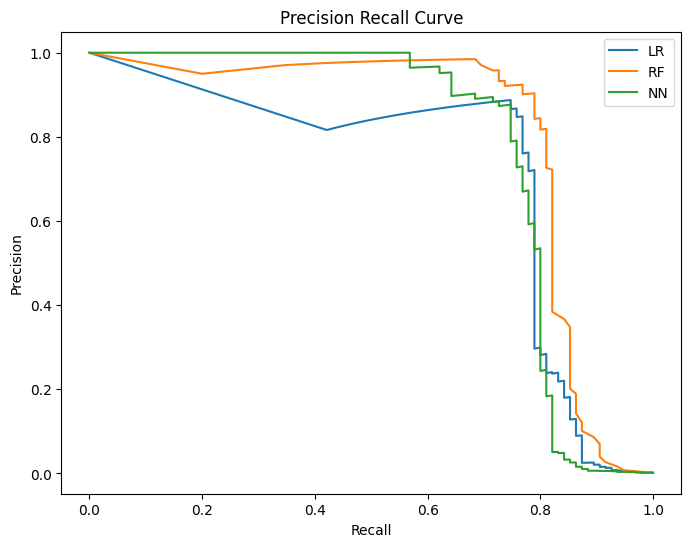

In [47]:
plt.figure(figsize=(8,6))

for model, name in [(lr,"LR"), (rf,"RF"), (mlp,"NN")]:

    probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, probs)

    plt.plot(recall, precision, label=name)

plt.legend()

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [48]:
results = pd.DataFrame({

'Model':['Logistic Regression','Random Forest','Neural Network'],

'Accuracy':[

accuracy_score(y_test, lr_pred),

accuracy_score(y_test, rf_pred),

accuracy_score(y_test, mlp_pred)

],

'Precision':[

precision_score(y_test, lr_pred),

precision_score(y_test, rf_pred),

precision_score(y_test, mlp_pred)

],

'Recall':[

recall_score(y_test, lr_pred),

recall_score(y_test, rf_pred),

recall_score(y_test, mlp_pred)

],

'F1':[

f1_score(y_test, lr_pred),

f1_score(y_test, rf_pred),

f1_score(y_test, mlp_pred)

],

'ROC AUC':[

roc_auc_score(y_test, lr_pred),

roc_auc_score(y_test, rf_pred),

roc_auc_score(y_test, mlp_pred)

]

})

print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC AUC
0  Logistic Regression  0.973725   0.053137  0.873684  0.100181  0.923788
1        Random Forest  0.999489   0.923077  0.757895  0.832370  0.878894
2       Neural Network  0.999242   0.782609  0.757895  0.770053  0.878771


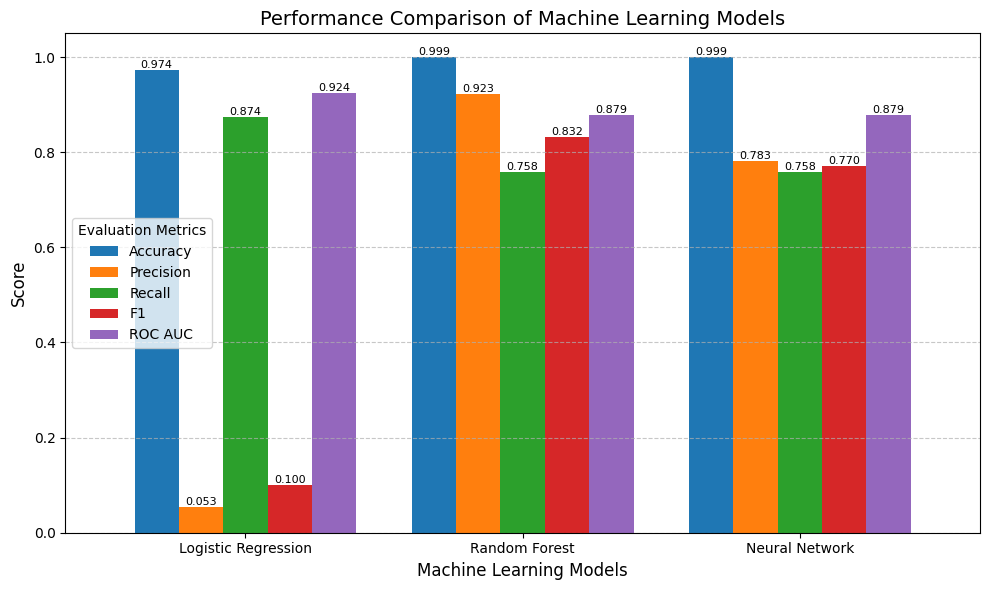

In [20]:
# -------------------------------
# Model Comparison Graph
# -------------------------------
import matplotlib.pyplot as plt

# Set Model as index
results_plot = results.set_index('Model')

# Plot grouped bar chart
ax = results_plot.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8
)

# Formatting
plt.title("Performance Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()